In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

df = pd.read_csv("youtube_videos.csv")

In [12]:
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


## Min-Max Scaling Subscribers

Compress data scale between 0-1

In [13]:
from sklearn.preprocessing import MinMaxScaler

# create column called "subscribers min-maxed"
scaler = MinMaxScaler()
df["subscribers_scaled"] = scaler.fit_transform(df[["subscribers"]])


In [14]:
df["subscribers_scaled"].describe()

count    210.000000
mean       0.128853
std        0.265999
min        0.000000
25%        0.002555
50%        0.016794
75%        0.061946
max        1.000000
Name: subscribers_scaled, dtype: float64

## Standard Scaling 'views'
Since `views` is heavily skewed, Min-max would compress 95% of the data near 0. We don't want to use this scaling on large datasets

With standarization, values are now centred around 0 with most videos between -1 and 2, outliers beyond that (ex. 5)

In [15]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
df["views_zscore"] = standard_scaler.fit_transform(df[["views"]])
df[["views", "views_zscore"]].describe()


,views,views_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


## Robust Scaling

Z-score still uses the mean thats pulled by outliers. This pulls the mean/std distorting the Z-scale for everyone else.

Robust scaling uses the median and IQR instead.

The outlier is visible but it no longer collapses everyone else to near zero.

In [16]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()
df["views_robust"] = robust_scaler.fit_transform(df[["views"]])
df[["views", "views_robust"]].describe()


,views,views_robust
count,2.100000e+02,210.000000
mean,5.485440e+05,1.608176
std,1.223751e+06,4.078175
min,1.412000e+03,-0.215152
25%,1.080400e+04,-0.183853
50%,6.597350e+04,0.000000
75%,3.108772e+05,0.816147
max,7.038551e+06,23.236251


## Log Transform

real-world variables grow exponentially: a small number of cases dominate the scale which compresses everything else to the left 

log transform pulls the long tail back in.

`views`, `subscribers`, and `watch_time_minutes` are all skewed to the right. 

A small channel with 1k views and a large channel with 7m views are worlds apart but models see them on a linear scale.
- The gap between Small and Large compresses from 7m to 8 log units - a scale a model can reason about


In [17]:
df["views_log"] = np.log1p(df["views"])
df["views"]

0       228102
1        25078
2      1323949
3       187752
4        12583
        ...   
205       6441
206       4755
207     104852
208       3026
209     145045
Name: views, Length: 210, dtype: int64

In [18]:
df["views_log"]

0      12.337553
1      10.129786
2      14.096130
3      12.142883
4       9.440181
         ...    
205     8.770594
206     8.467162
207    11.560315
208     8.015327
209    11.884806
Name: views_log, Length: 210, dtype: float64

### Before Log Transformation

<Axes: xlabel='views', ylabel='Count'>

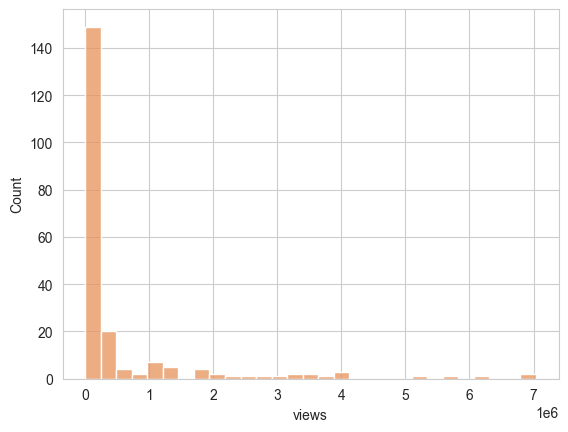

In [24]:
sns.histplot(df["views"], color="#e8925a")

### After Log Transformation

<Axes: xlabel='views_log', ylabel='Count'>

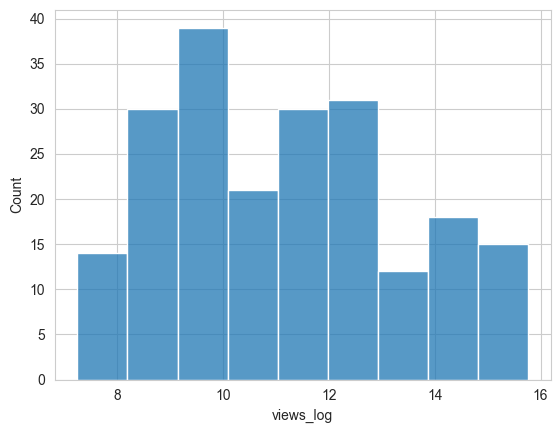

In [20]:
sns.histplot(df["views_log"])

## Binning 
Continuous number is less meaningful to us
- Model doesn't need to know if a video is exactly 743 seconds - just needs to know its a **medium-length video**

Binning converts continuous feature into **ordered groups**

`duration_seconds` ranges from 2 minutes to 4 hours.
YouTube creators and viewers think in terms of short clips, standard videos, and long-form content — not raw seconds.

<Axes: xlabel='duration_bin', ylabel='count'>

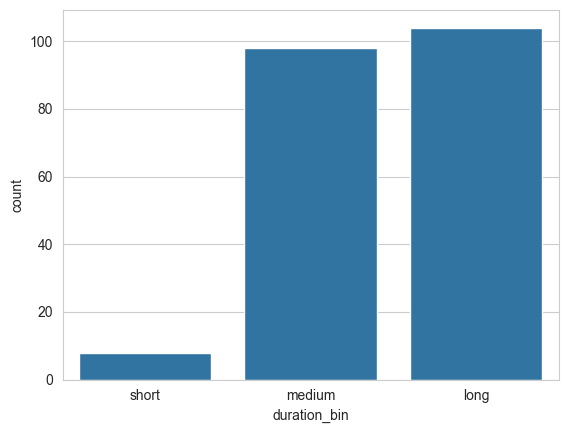

In [ ]:
# bin categories, x < 300 = short, float infinity
bins = [0, 300, 1800, float("inf")]
labels = ["short", "medium", "long"]

df["duration_bin"] = pd.cut(df["duration_seconds"],bins=bins,labels=labels)

#countplot because its categorical
# histogram is the same but with equal bin sizes
sns.countplot(x="duration_bin", data=df)



## Custom Binning
for `likes`, `comments`, and `shares`

### Shares

In [27]:
df["shares"].describe()

count      210.000000
mean      3947.052381
std       8731.782974
min          5.000000
25%         65.500000
50%        335.000000
75%       2243.250000
max      48004.000000
Name: shares, dtype: float64

In [36]:
share_bins = [0, 2000, 10000, 20000, float("inf")]
share_labels = ["niche", "known", "popular", "viral"]

df["shares_bin"] = pd.cut(df["shares"],bins=share_bins,labels=share_labels)


[Text(0.5, 1.0, 'Video Shares')]

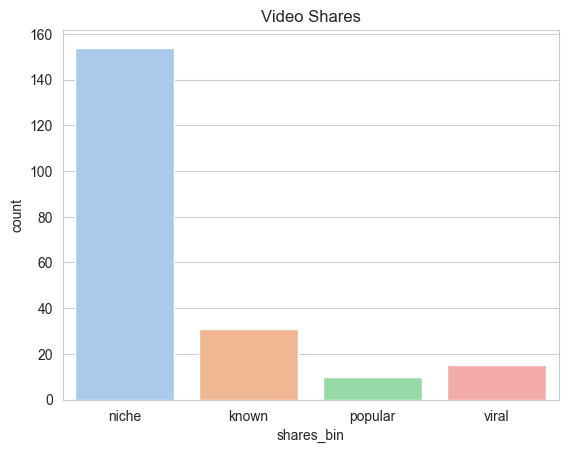

In [75]:
sns.countplot(x="shares_bin", data=df, dodge=False, hue="shares_bin").set(title="Video Shares")

## Ordinal Encoding 

Ordinal encoding maps each category to an integer that reflects its rank
- Treating them as arbitrary labels throws that information away.

Small→0 Mid→1 Large→2

`channel_tier` has a clear ordering
- Small channels have less subscribers, views, and reach than mid or large
- The model should know Large > Mid > Small

In [78]:
df["channel_tier"].unique()

<StringArray>
['Mid', 'Small', 'Large']
Length: 3, dtype: str

In [79]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[["Small", "Mid", "Large"]])

#it will give you a floating number so add .astype(int) to get a interger
df[["channel_tier_encoded"]] = encoder.fit_transform(df[["channel_tier"]]).astype(int)

df[["channel_tier","channel_tier_encoded"]]



,channel_tier,channel_tier_encoded
0,Mid,1
1,Small,0
2,Large,2
3,Mid,1
4,Small,0
...,...,...
205,Small,0
206,Small,0
207,Mid,1
208,Small,0


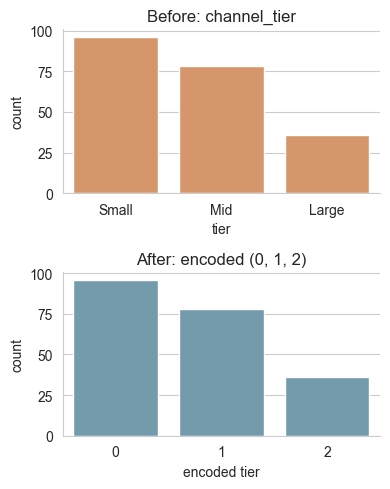

In [80]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

order_str = ["Small", "Mid", "Large"]
sns.countplot(data=df,
              x="channel_tier",
              order=order_str,
              color="#e8925a",
              ax=axes[0])
axes[0].set_title("Before: channel_tier")
axes[0].set_xlabel("tier")

order_num = [0, 1, 2]
sns.countplot(data=df,
              x="channel_tier_encoded",
              color="#6a9fb5",
              ax=axes[1])
axes[1].set_title("After: encoded (0, 1, 2)")
axes[1].set_xlabel("encoded tier")

sns.despine()
plt.tight_layout()
plt.show()

## One-Hot Encoding 
When categories have no natural order, assigning integers is misleading
- Gaming = "3" and Music = "1" means the model will think Gaming > Music

One-hot encoding creates a separate binary column for each category
- no false ordering imposed

`category` has 6 unordered values: Tutorial, Review, News & Opinion, Project Showcase, Debate & Controversy, Productivity & Tools.

A model treating these as 0–5 would wrongly assume Productivity (5) is “more” than Tutorial (0).

The tradeoff: way, way more columns of just one type

In [82]:
hot_encoding = pd.get_dummies(df["category"], prefix="is")

hot_encoding

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


### Concat and join the original dataset with the new features

In [83]:
result = pd.concat([df[["video_id", "category"]], hot_encoding], axis=1)

#creates a bunch of boolean categories
print(result.head(6).to_string(index=False))

video_id category  is_Comedy  is_Education  is_Gaming  is_Music  is_News  is_Vlog
vid_0000    Music      False         False      False      True    False    False
vid_0001   Gaming      False         False       True     False    False    False
vid_0002   Gaming      False         False       True     False    False    False
vid_0003   Gaming      False         False       True     False    False    False
vid_0004    Music      False         False      False      True    False    False
vid_0005     News      False         False      False     False     True    False


## Date & Time Features 

Raw timestamps aren’t useful to a model but the patterns are
- When a video was uploaded > what it contains

A model can’t learn from “Saturday” — but it can learn from is_weekend = 1.

`upload_day` and `upload_hour` are already extracted in our dataset.
We can engineer two binary features directly from them: `is_weekend` and `is_primetime`

In [ ]:
# simulate a full timestamp from existing day/hour columns
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}

#create random timestamps just for this lab
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

# extract features from timestamp
df["is_weekend"] = (df["uploaded_at"].dt.dayofweek >= 5).astype(int)

df["is_primetime"] = ((df["uploaded_at"].dt.hour >= 18) &(df["uploaded_at"].dt.hour <= 22)).astype(int)

In [90]:
df["uploaded_at"]

0     2024-01-07 00:05:00
1     2024-01-06 21:46:00
2     2024-01-08 18:39:00
3     2024-01-04 14:26:00
4     2024-01-08 04:25:00
              ...        
205   2024-01-05 13:15:00
206   2024-01-06 08:45:00
207   2024-01-07 20:58:00
208   2024-01-04 21:15:00
209   2024-01-05 10:46:00
Name: uploaded_at, Length: 210, dtype: datetime64[us]

In [91]:
df["uploaded_at"].dt.dayofweek

0      6
1      5
2      0
3      3
4      0
      ..
205    4
206    5
207    6
208    3
209    4
Name: uploaded_at, Length: 210, dtype: int32

# Unstructured Data
## Text Analysis `title`
Raw title text is useless to a model
- But patterns within text carry signal

Counting ALL CAPS words is a simple domain knowledge feature 

In [95]:
df["title"]

0      I tried EVERY transformers tool — the WINNER s...
1             What nobody tells you about AI image tools
2      What nobody tells you about machine learning p...
3                            Is Claude worth it in 2025?
4      URGENT: voice cloning AI is about to CHANGE FO...
                             ...                        
205    STOP using Python for AI WRONG (most people do...
206    I built a machine learning pipelines project —...
207                   What nobody tells you about Gemini
208    Why deep learning frameworks DESTROYED my work...
209                         GPT-4 is DEAD and here's WHY
Name: title, Length: 210, dtype: str

### ALL CAPS count — in our dataset
 Does the number of ALL CAPS words correlate with views?

In [ ]:
#run an anonymous function on every row, and then return a value in the column you want

# lamba = anon function
# t = text
# 1 for every word (w) in split text
# if w is uppercase 

# This gets you the count of uppercase/cap words in that title 
# as a straight code line:
df["caps_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.isupper())
)

# as a defined function:
def countCaps(t):
    sum = 0 #initalize a number
    words = t.split()
    for word in words:
        if word.isupper(): sum = sum+1
    return sum


df["caps_count"]

0      3
1      1
2      0
3      0
4      4
      ..
205    3
206    2
207    0
208    2
209    3
Name: caps_count, Length: 210, dtype: int64

In [ ]:
#apply function
df["title"].apply(countCaps)

0      3
1      1
2      0
3      0
4      4
      ..
205    3
206    2
207    0
208    2
209    3
Name: title, Length: 210, dtype: int64

## Bag of Words: From text to numbers — word counts
Bag of Words
- count how many times each word appears in each document
- order doesn’t matter, only counts

Each row is now a vector of numbers 

### The problem with raw counts: “I”, “the”, “is”
These appear everywhere but carry no meaningful information.

it tells us nothing about what makes each title distinctive.
We need a way to reward rare, meaningful words and penalize common ones.

### TF-IDF 
TF-IDF = Term Frequency × Inverse Document Frequency

    TF — how often does this word appear in this document?
    IDF — how rare is this word across all documents?


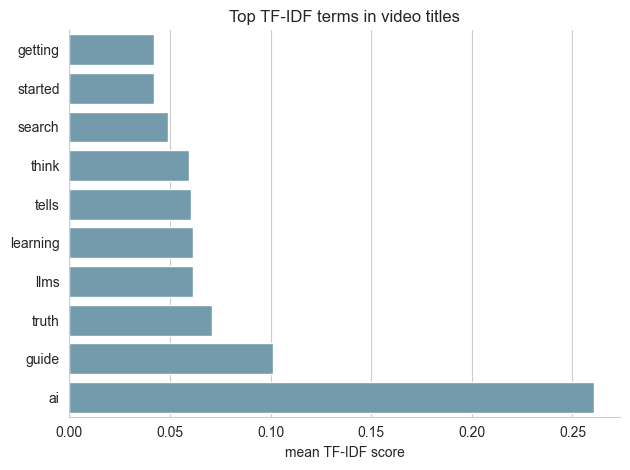

In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

# Ratios & Interaction Features
Combining existing features to reveal relationships a model can’t see on its own.

## Ratios 

A video with 10,000 `comments` means something very different with 100K `views` vs 10M `views`.

Dividing one feature by another creates a normalized signal — one that accounts for scale:
- retention rate = watch time minutes DIVIDED BY duration seconds/60
- did viewers stay? independent of view count

Two videos can have the same watch_time_minutes for very different reasons — one is short and rewatched, one is long and abandoned halfway

In [108]:
df["duration_minutes"] = df["duration_seconds"] / 60

df["retention_rate"] = (df["watch_time_minutes"] / (df["views"] * df["duration_minutes"])
).clip(0, 1) #clip it to be between 0 and 1 only (gives us a int percentage like 0.95)

df[["watch_time_minutes", "duration_seconds", "retention_rate"]]

,watch_time_minutes,duration_seconds,retention_rate
0,1091087,721,0.398058
1,423818,1894,0.535375
2,12952634,1413,0.415428
3,2018334,1335,0.483146
4,262565,3158,0.396453
...,...,...,...
205,87597,1737,0.469772
206,132347,5776,0.289126
207,2266550,2617,0.495605
208,97538,3656,0.528993


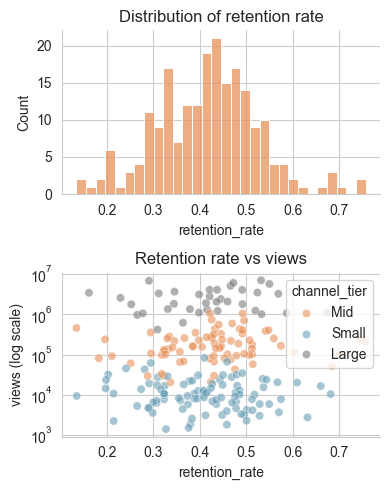

In [107]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["retention_rate"],
             bins=30,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of retention rate")
axes[0].set_xlabel("retention_rate")

sns.scatterplot(data=df,
                x="retention_rate",
                y="views",
                hue="channel_tier",
                palette={"Small": "#6a9fb5",
                         "Mid": "#e8925a",
                         "Large": "#7a7a7a"},
                alpha=0.6,
                ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Retention rate vs views")
axes[1].set_xlabel("retention_rate")
axes[1].set_ylabel("views (log scale)")

sns.despine()
plt.tight_layout()
plt.show()

## Interaction Features 
two features combine to create a signal neither carries alone
- large channel with low click-through rate and a small channel with high click-through rate are very different situations

Multiplying features creates an interaction term that captures this joint effect:

reach potential (expected viewers) = subscribers × click through rate

In [109]:
df["reach_potential"] = (df["subscribers"] * df["click_through_rate"])

df[["subscribers", "click_through_rate", "reach_potential"]]

,subscribers,click_through_rate,reach_potential
0,441016,0.0100,4410.1600
1,25339,0.0230,582.7970
2,2398429,0.1022,245119.4438
3,498144,0.0413,20573.3472
4,30039,0.0100,300.3900
...,...,...,...
205,13428,0.1004,1348.1712
206,10005,0.0330,330.1650
207,483919,0.0604,29228.7076
208,11937,0.0541,645.7917


## Multi-Label Encoding
When a single cell contains multiple values, each needs its own column.

Some features are naturally a list 
- a video can belong to multiple hashtag communities 
- `hashtags` : [“ai”, “tutorial”, “trending”]

A single column can’t capture this. We need one binary column per possible value.
- similar to one-hot encoding — but a row can have multiple 1s at once
- unlike one-hot encoding where exactly one column is 1.

In [110]:
import json
from sklearn.preprocessing import MultiLabelBinarizer

df["hashtags"] = df["hashtags"].apply(json.loads)

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(mlb.fit_transform(df["hashtags"]), columns=mlb.classes_, index=df.index)

result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0
